In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename

In [2]:
# Read in the current baseline
db_file = "baseline_v5.3.3_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)

In [3]:
ack = np.unique(visits_array["scheduler_note"])

In [4]:
bs_list = [note.split(',')[2].split(' ')[-1] for note in ack if "pair" in note]

In [5]:
ack = np.array(bs_list).astype(int)

In [8]:
ack.min(), ack.max()

(np.int64(35), np.int64(62))

In [7]:
ack

array([35, 35, 36, 36, 37, 37, 38, 38, 39, 39, 40, 40, 41, 41, 42, 42, 43,
       43, 44, 44, 45, 45, 46, 46, 47, 47, 48, 48, 49, 49, 50, 50, 51, 51,
       52, 52, 53, 53, 54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59, 59, 60,
       60, 61, 61, 62, 62, 35, 35, 36, 36, 37, 37, 38, 38, 39, 39, 40, 40,
       41, 41, 42, 42, 43, 43, 44, 44, 45, 45, 46, 46, 47, 47, 48, 48, 49,
       49, 50, 50, 51, 51, 52, 52, 53, 53, 54, 54, 55, 55, 56, 56, 57, 57,
       58, 58, 59, 59, 60, 60, 61, 61, 62, 62, 35, 35, 36, 36, 37, 37, 38,
       38, 39, 39, 40, 40, 41, 41, 42, 42, 43, 43, 44, 44, 45, 45, 46, 46,
       47, 47, 48, 48, 49, 49, 50, 50, 51, 51, 52, 52, 53, 53, 54, 54, 55,
       55, 56, 56, 57, 57, 58, 58, 59, 59, 60, 60, 61, 61, 62, 62, 36, 36,
       37, 37, 38, 38, 39, 39, 40, 40, 41, 41, 42, 42, 43, 43, 44, 44, 45,
       45, 46, 46, 47, 47, 48, 48, 49, 49, 50, 50, 51, 51, 52, 52, 53, 53,
       54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59, 59, 60, 60, 61, 61, 62,
       62, 35, 35, 36, 36

In [16]:
bs_list = [note.split(',')[2].split(' ')[-1] for note in visits_array["scheduler_note"] if "pair" in note]

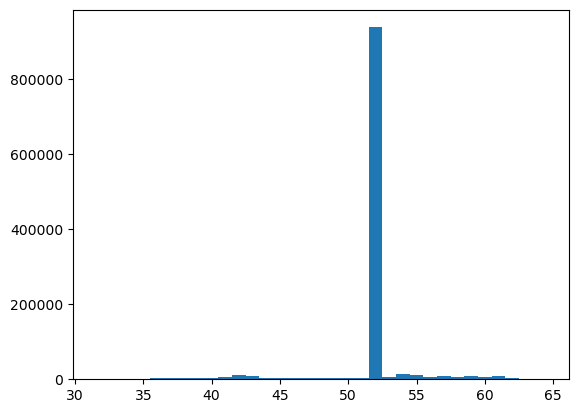

In [17]:
_ack = plt.hist(np.array(bs_list).astype(int), bins=np.arange(32, 66)-0.5)

In [15]:
len(bs_list)

386